# Week 3: Perceptron for an OR Logic Gate

## Step 1 — Import Libraries and Create the Dataset

This exercise implements a perceptron from scratch and trains it to reproduce the behaviour of an OR logic gate.

- **NumPy** performs numerical operations and stores the dataset as arrays.
- **Matplotlib** creates graphs and visualises the perceptron's decision boundary.
- The OR dataset is linearly separable, meaning a single straight decision boundary can separate its two output classes.

In [8]:
# Import NumPy and give it the standard short name "np".
# NumPy provides arrays, dot products and other numerical operations
# required by the perceptron.
import numpy as np

# Import the pyplot section of Matplotlib and call it "plt".
# We will use it later to display the training results and
# the perceptron's decision boundary.
import matplotlib.pyplot as plt

# Display a message confirming that this cell ran successfully.
print("NumPy and Matplotlib imported successfully.")

NumPy and Matplotlib imported successfully.


In [10]:
# Create the input data for the OR logic gate.
#
# Each row represents one training example.
# Column 1 contains the value of input x1.
# Column 2 contains the value of input x2.
X_or = np.array([
    [0, 0],  # 0 OR 0
    [0, 1],  # 0 OR 1
    [1, 0],  # 1 OR 0
    [1, 1]   # 1 OR 1
])

# Create the correct output for each row in X_or.
#
# The outputs follow the OR rule:
# 0 OR 0 = 0
# 0 OR 1 = 1
# 1 OR 0 = 1
# 1 OR 1 = 1
y_or = np.array([0, 1, 1, 1])

# Display the dataset so that we can check it.
print("OR-gate inputs:")
print(X_or)

print("\nExpected outputs:")
print(y_or)

# Display the dimensions of both arrays.
# X_or has four rows and two input features.
# y_or contains four corresponding target values.
print("\nInput array shape:", X_or.shape)
print("Target array shape:", y_or.shape)

OR-gate inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Expected outputs:
[0 1 1 1]

Input array shape: (4, 2)
Target array shape: (4,)


## Step 2 — Define the Perceptron Class

The `Perceptron` class contains three main parts:

1. `__init__()` creates the model and stores its settings.
2. `predict()` calculates binary predictions.
3. `fit()` trains the model by updating its weights and bias whenever it makes an incorrect prediction.

In [11]:
# Define a class representing a perceptron model.
class Perceptron:

    # The constructor runs when we create a new Perceptron object.
    def __init__(self, learning_rate=0.1, epochs=20):

        # Store the learning rate.
        # This controls the size of each weight and bias update.
        self.lr = learning_rate

        # Store the number of epochs.
        # One epoch means one complete pass through the dataset.
        self.epochs = epochs

        # The weights will be created when training begins.
        self.weights = None

        # The bias will also be created when training begins.
        self.bias = None

        # This list will record the number of mistakes in each epoch.
        self.errors_per_epoch = []

    # Define a method that calculates predictions.
    def predict(self, X):

        # Calculate the weighted sum:
        # z = (X × weights) + bias
        linear_output = np.dot(X, self.weights) + self.bias

        # Apply the step activation function.
        # Return 1 when the weighted sum is zero or greater.
        # Otherwise, return 0.
        return np.where(linear_output >= 0, 1, 0)

    # Define a method that trains the perceptron.
    def fit(self, X, y):

        # Read the dimensions of the input dataset.
        # n_samples is the number of rows.
        # n_features is the number of input columns.
        n_samples, n_features = X.shape

        # Start with one weight of zero for each input feature.
        # The OR dataset has two features, so it receives two weights.
        self.weights = np.zeros(n_features)

        # Start the bias at zero.
        self.bias = 0.0

        # Clear any error history from earlier training.
        self.errors_per_epoch = []

        # Repeat the training process for the selected number of epochs.
        for epoch in range(self.epochs):

            # Begin this epoch with zero recorded mistakes.
            errors = 0

            # Process each input row together with its correct target.
            for xi, target in zip(X, y):

                # Calculate the weighted sum for the current example.
                linear_output = np.dot(xi, self.weights) + self.bias

                # Apply the step activation function.
                prediction = 1 if linear_output >= 0 else 0

                # Calculate the perceptron's learning update.
                #
                # Correct prediction:
                # target - prediction = 0, so nothing changes.
                #
                # Incorrect prediction:
                # the weights and bias are adjusted.
                update = self.lr * (target - prediction)

                # Update every weight using the corresponding input value.
                self.weights += update * xi

                # Update the bias.
                self.bias += update

                # Record a mistake if an update was required.
                if update != 0:
                    errors += 1

            # Save the number of mistakes made during this epoch.
            self.errors_per_epoch.append(errors)

        # Return the trained object.
        # This allows calls such as model.fit(X, y).predict(X).
        return self


# Confirm that the class-definition cell ran successfully.
print("Perceptron class defined successfully.")

Perceptron class defined successfully.


## Step 3 — Train the Perceptron

We now create a perceptron and train it using the OR-gate dataset.

During training, the model repeatedly examines the four input combinations and adjusts its weights and bias whenever its prediction is incorrect.

After training, we compare the model's predictions with the expected OR-gate outputs.

In [12]:
# Create a new perceptron model.
#
# learning_rate=0.1 means each correction is made in steps of 0.1.
# epochs=20 means the model can examine the complete dataset 20 times.
p_or = Perceptron(learning_rate=0.1, epochs=20)

# Train the perceptron using:
# X_or = the four input combinations.
# y_or = the four correct OR-gate outputs.
p_or.fit(X_or, y_or)

# Use the trained model to predict the outputs for the OR inputs.
predictions = p_or.predict(X_or)

# Display the parameters learned during training.
print("Learned weights:", p_or.weights)
print("Learned bias:", p_or.bias)

# Compare the expected outputs with the model's predictions.
print("\nExpected outputs:", y_or)
print("Model predictions:", predictions)

# Calculate the proportion of correct predictions.
accuracy = np.mean(predictions == y_or)

# Convert the accuracy from a decimal to a percentage.
print(f"\nTraining accuracy: {accuracy * 100:.1f}%")

# Display how many errors occurred during every training epoch.
print("Errors per epoch:", p_or.errors_per_epoch)

Learned weights: [0.1 0.1]
Learned bias: -0.1

Expected outputs: [0 1 1 1]
Model predictions: [0 1 1 1]

Training accuracy: 100.0%
Errors per epoch: [2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Step 4 — Visualise the Training Errors

The following graph shows how many examples the perceptron classified incorrectly during each epoch.

A reduction to zero errors indicates that the perceptron has converged and successfully learned the OR-gate pattern.

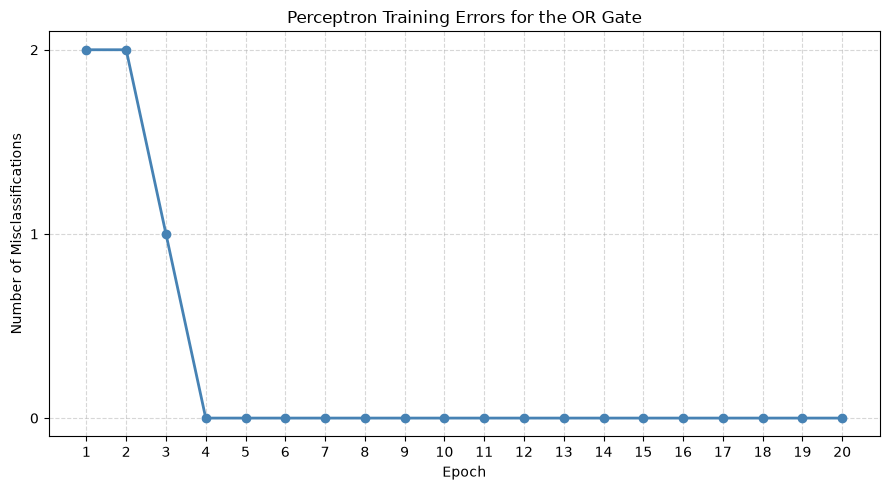

In [13]:
# Create epoch numbers beginning at 1.
# For 20 epochs, this produces the numbers 1 through 20.
epoch_numbers = range(1, len(p_or.errors_per_epoch) + 1)

# Create a new figure with a width of 9 inches
# and a height of 5 inches.
plt.figure(figsize=(9, 5))

# Plot the number of errors recorded during each epoch.
#
# marker="o" places a circular marker at every epoch.
# linewidth=2 controls the thickness of the line.
# color="steelblue" sets the line and marker colour.
plt.plot(
    epoch_numbers,
    p_or.errors_per_epoch,
    marker="o",
    linewidth=2,
    color="steelblue"
)

# Add a descriptive title to the graph.
plt.title("Perceptron Training Errors for the OR Gate")

# Label the horizontal axis.
plt.xlabel("Epoch")

# Label the vertical axis.
plt.ylabel("Number of Misclassifications")

# Display every epoch number along the horizontal axis.
plt.xticks(epoch_numbers)

# Use whole numbers on the vertical axis because
# the number of errors cannot be a decimal value.
maximum_errors = max(p_or.errors_per_epoch)
plt.yticks(range(0, maximum_errors + 1))

# Add a light grid to make the values easier to read.
plt.grid(True, linestyle="--", alpha=0.5)

# Adjust the spacing so that labels are not cut off.
plt.tight_layout()

# Display the completed graph.
plt.show()

## Step 5 — Visualise the Decision Boundary

The decision boundary shows how the trained perceptron divides the input space into two prediction regions:

- **Class 0:** the output is false.
- **Class 1:** the output is true.

Because the OR gate is linearly separable, one straight boundary can separate `[0, 0]` from the other three input combinations.

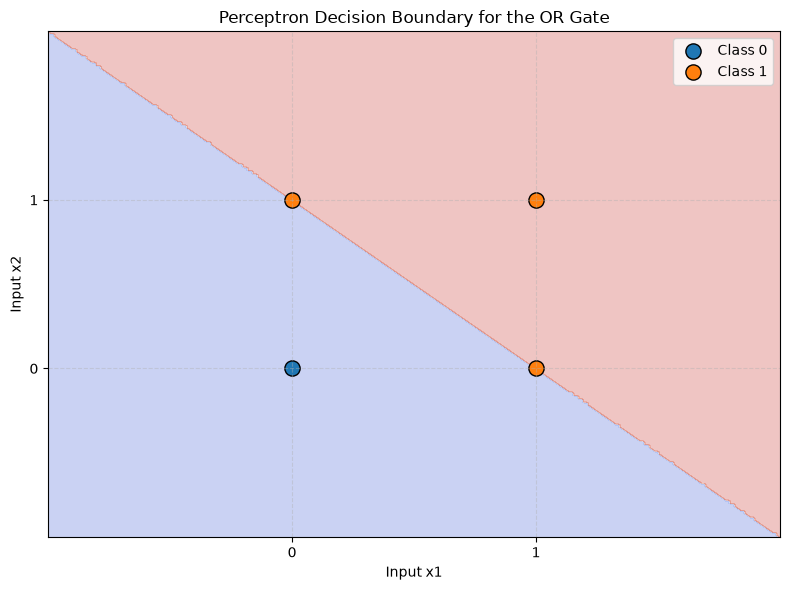

In [14]:
# Define a reusable function for drawing a model's decision boundary.
def plot_decision_boundary(X, y, model, title):

    # Find the minimum and maximum values in the first input column.
    # The additional space makes the graph easier to read.
    x1_min = X[:, 0].min() - 1
    x1_max = X[:, 0].max() + 1

    # Find the minimum and maximum values in the second input column.
    x2_min = X[:, 1].min() - 1
    x2_max = X[:, 1].max() + 1

    # Create 300 evenly spaced values across each axis.
    x1_values = np.linspace(x1_min, x1_max, 300)
    x2_values = np.linspace(x2_min, x2_max, 300)

    # Combine the axis values into a two-dimensional coordinate grid.
    xx, yy = np.meshgrid(x1_values, x2_values)

    # Flatten the coordinate grid and combine both coordinates.
    # Each row in "grid" represents one point to classify.
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Ask the trained model to predict the class of every grid point.
    grid_predictions = model.predict(grid)

    # Return the flat predictions to the shape of the coordinate grid.
    Z = grid_predictions.reshape(xx.shape)

    # Create the graph.
    plt.figure(figsize=(8, 6))

    # Colour the background according to the predicted class.
    # Blue represents class 0 and red represents class 1.
    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap="coolwarm"
    )

    # Plot the original OR-gate samples one class at a time.
    for label in np.unique(y):

        # Select only the input rows belonging to this class.
        class_points = X[y == label]

        # Draw the selected points.
        plt.scatter(
            class_points[:, 0],
            class_points[:, 1],
            s=120,
            edgecolor="black",
            label=f"Class {label}"
        )

    # Add the graph title and axis labels.
    plt.title(title)
    plt.xlabel("Input x1")
    plt.ylabel("Input x2")

    # Display a legend explaining the two classes.
    plt.legend()

    # Display the main OR-gate input values on both axes.
    plt.xticks([0, 1])
    plt.yticks([0, 1])

    # Add a light grid.
    plt.grid(True, linestyle="--", alpha=0.4)

    # Adjust the layout and display the graph.
    plt.tight_layout()
    plt.show()


# Call the function using the OR dataset and trained perceptron.
plot_decision_boundary(
    X=X_or,
    y=y_or,
    model=p_or,
    title="Perceptron Decision Boundary for the OR Gate"
)

## Step 6 — Evaluate Individual Predictions

The following table compares the expected OR-gate output with the output predicted by the trained perceptron.

A correct prediction for all four combinations confirms that the model has successfully learned the OR function.

In [15]:
# Generate predictions for all four OR-gate inputs.
final_predictions = p_or.predict(X_or)

# Print a heading for the results table.
print("x1 | x2 | Expected | Predicted | Correct")
print("-" * 43)

# Examine each input, expected answer and prediction together.
for inputs, expected, predicted in zip(
    X_or,
    y_or,
    final_predictions
):
    # Separate the two input values.
    x1, x2 = inputs

    # Check whether the prediction matches the expected result.
    is_correct = expected == predicted

    # Convert the Boolean result into a readable label.
    result = "Yes" if is_correct else "No"

    # Print one formatted row of the table.
    print(
        f"{x1:>2} | {x2:>2} |"
        f"{expected:>9} |"
        f"{predicted:>10} | {result}"
    )

# Calculate the number of correct predictions.
correct_predictions = np.sum(final_predictions == y_or)

# Calculate the final accuracy.
final_accuracy = np.mean(final_predictions == y_or) * 100

# Display the overall evaluation.
print("\nCorrect predictions:", correct_predictions, "out of", len(y_or))
print(f"Final accuracy: {final_accuracy:.1f}%")

x1 | x2 | Expected | Predicted | Correct
-------------------------------------------
 0 |  0 |        0 |         0 | Yes
 0 |  1 |        1 |         1 | Yes
 1 |  0 |        1 |         1 | Yes
 1 |  1 |        1 |         1 | Yes

Correct predictions: 4 out of 4
Final accuracy: 100.0%


## Conclusion

A perceptron was implemented from scratch and trained using the four possible inputs of an OR logic gate.

The model learned by:

1. Calculating a weighted sum from the inputs, weights and bias.
2. Applying a step activation function to produce either `0` or `1`.
3. Comparing its prediction with the expected output.
4. Updating its weights and bias whenever the prediction was incorrect.
5. Repeating this process across multiple epochs.

The trained model correctly predicted all four OR-gate outputs and achieved **100% training accuracy**.

The error graph demonstrated that the number of misclassifications eventually reached zero. The decision-boundary graph also showed that the two output classes could be separated using a straight line.

This experiment works because the OR gate is **linearly separable**. However, a single perceptron cannot learn a non-linearly separable problem such as XOR. Solving XOR requires a model containing multiple connected neurons or hidden layers.